# New York's siting clock: rebuilding the chart from the source

This notebook downloads two official New York reports, finds each number on its page, checks it, and redraws the chart used in the LinkedIn post *AI won't fix permitting on its own*.

## Step 0. Set up

You need Python 3 with `requests`, `pypdf`, `pandas` and `matplotlib`
(`pip install requests pypdf pandas matplotlib`). Run the cells from top to bottom.
Downloaded documents go in `sources/`; the finished chart goes in `output/`.

In [1]:
# Chart style used on every chart: Google Sans if installed, white background, quiet grid,
# vertical columns, both axes drawn, sources printed with links in [brackets].
import logging
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
for font_file in Path.home().glob("Library/Fonts/GoogleSans-*.ttf"):
    font_manager.fontManager.addfont(str(font_file))
plt.rcParams.update({
    "font.family": ["Google Sans", "Arial", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#14213D",
    "axes.linewidth": 1.2,
    "axes.labelcolor": "#4F5B6E",
    "xtick.color": "#14213D",
    "ytick.color": "#4F5B6E",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#E3E6EB",
    "figure.facecolor": "white",
})
BLUE, GREY, INK, MUTED = "#1F56A8", "#8A94A6", "#14213D", "#4F5B6E"

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)


def frame_chart(fig, title, subtitle, sources, credit="Chart: Amy Chen"):
    """Title = the one takeaway; subtitle = what is plotted; footer = every source with its link."""
    fig.text(0.06, 0.94, title, fontsize=21, fontweight="bold", color=INK, va="top", wrap=True)
    fig.text(0.06, 0.865, subtitle, fontsize=13, color=MUTED, va="top")
    y = 0.075 + 0.032 * (len(sources) - 1)
    for label, url in sources:
        fig.text(0.06, y, f"Source: {label} [{url}]", fontsize=8.5, color=MUTED)
        y -= 0.032
    fig.text(0.94, 0.03, credit, fontsize=9, color=MUTED, ha="right")

In [2]:
# Download a file once and keep it in ./sources, so every later step reads the same copy.
import requests

SOURCES = Path("sources")
SOURCES.mkdir(exist_ok=True)
HEADERS = {"User-Agent": "Mozilla/5.0 (research notebook; reproducing a published chart)"}


def download(url, filename):
    path = SOURCES / filename
    if not path.exists():
        response = requests.get(url, headers=HEADERS, timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)
    print(f"{filename}: {path.stat().st_size:,} bytes")
    return path

In [3]:
# Read one page of a PDF as plain text, and print the sentence around a phrase.
import re

from pypdf import PdfReader


def page_text(pdf_path, page_number):
    """page_number is the PDF page (1 = first page of the file), not the number printed on the page."""
    text = PdfReader(pdf_path).pages[page_number - 1].extract_text()
    return " ".join(text.split())


def quote(text, phrase, before=220, after=200):
    at = text.find(phrase)
    assert at >= 0, f"'{phrase}' not found: the source may have changed"
    return "…" + text[max(0, at - before): at + len(phrase) + after] + "…"

## Step 1. Download the New York State Comptroller's audit (2024)

Audit 2023-S-52 reviewed how long the Office of Renewable Energy Siting (ORES) took to permit
large renewable projects, 2020–2023.

In [4]:
audit = download("https://www.osc.ny.gov/files/state-agencies/audits/pdf/sga-2024-23s52.pdf",
                 "ny-comptroller-audit-2023-S-52.pdf")

ny-comptroller-audit-2023-S-52.pdf: 1,199,661 bytes


## Step 2. Find the two numbers on page 11

Page 11 states the average time **to get an application declared complete** (1,094 days)
and the average **whole process** (1,333 days). Its Figure 1 adds that the stage after
completeness took 239 days, and prints the check `1,094 + 239 = 1,333`.

In [5]:
p11 = page_text(audit, 11)
print(quote(p11, "1,094 days"))
print()
print(quote(p11, "Note: 1,094 + 239 = 1,333", before=40, after=120))

… 94-C took an average of 1,268 days (3.5 years) for their application to be deemed complete. Finally, for the 14 projects that received final siting permits from ORES, we found it took slightly less time – an average of 1,094 days (3 years) – to deem the application complete. For these 14 projects, it took an average of 1,333 days (3.7 years) from the initial application date to issue the final siting permit. Some of the delay…

…itted Projects 49 days 65 days days 239 Note: 1,094 + 239 = 1,333, the average number of days from the initial application to the final siting permit.…


In [6]:
to_complete_2020_23 = 1094      # filed -> declared complete (no overall deadline)
after_complete_2020_23 = 239     # declared complete -> permit (the 1-year legal deadline applies here)
total_2020_23 = 1333

assert "1,094 days" in p11 and "1,333 days" in p11 and "1,094 + 239 = 1,333" in p11
assert to_complete_2020_23 + after_complete_2020_23 == total_2020_23
print("2020-23 numbers match page 11.")

2020-23 numbers match page 11.


## Step 3. Confirm what the 1-year deadline covers (page 8)

The law gives ORES 60 days to review each submission for completeness, and one year to decide
**from the date the application is deemed complete**. Each incomplete filing goes back to the developer,
and the 60-day review starts again on resubmission.

In [7]:
p8 = page_text(audit, 8)
print(quote(p8, "within 1 year from the date the application was deemed", before=120, after=40))
print()
print(quote(p8, "Each time a notice of incomplete application is filed", before=10, after=160))

…energy facility. ORES must make a final decision and issue a final siting permit for any major renewable energy project within 1 year from the date the application was deemed…

…ithdrawn. Each time a notice of incomplete application is filed, the clock resets for ORES. ORES has another 60 days to review the application after the missing documentation is submitted. If ORES fails to make a determinat…


## Step 4. Download ORES's own Annual Report 2025 and read the 2025 row (page 8)

The table on page 8 lists, by year, how many permits were approved and the average days in each stage.

In [8]:
ores = download("https://dps.ny.gov/system/files/documents/2026/05/ores-annual-report-2025.pdf",
                "ores-annual-report-2025.pdf")
ores_p8 = page_text(ores, 8)
print(quote(ores_p8, "2025 9", before=330, after=40))

ores-annual-report-2025.pdf: 487,361 bytes
…lications for facilities proposed on a repurposed site. 3. Comparison 2021-2025 (Permits approved -- averages) Year Total Permits Approved Average Days from Application Submission to Complete Application Average Days from Complete Application to Final Permit Issuance 2021 2 03 1664 2022 6 1215 2536 2023 7 262 278 2024 4 315 289 2025 9 277 262 Total 28 225 261 The Office has…


In [9]:
row = re.search(r"2025 (\d+) (\d+) (\d+)", ores_p8)
permits_2025, to_complete_2025, after_complete_2025 = map(int, row.groups())
print(f"2025: {permits_2025} permits, {to_complete_2025} days to complete, {after_complete_2025} days to decision")
assert (permits_2025, to_complete_2025, after_complete_2025) == (9, 277, 262)

2025: 9 permits, 277 days to complete, 262 days to decision


## Step 5. Put the four numbers in one table

In [10]:
import pandas as pd

table = pd.DataFrame({
    "period": ["2020–23", "2025"],
    "filed_to_complete_days": [to_complete_2020_23, to_complete_2025],
    "complete_to_permit_days": [after_complete_2020_23, after_complete_2025],
    "source": ["Comptroller audit 2023-S-52, p. 11 (14 permitted projects)", "ORES Annual Report 2025, p. 8 (9 permits)"],
})
table["total_days"] = table.filed_to_complete_days + table.complete_to_permit_days
table["share_under_deadline"] = (table.complete_to_permit_days / table.total_days).round(2)
table.to_csv(OUTPUT / "ny_siting_stages.csv", index=False)
table

,period,filed_to_complete_days,complete_to_permit_days,source,total_days,share_under_deadline
0,2020–23,1094,239,"Comptroller audit 2023-S-52, p. 11 (14 permitt...",1333,0.18
1,2025,277,262,"ORES Annual Report 2025, p. 8 (9 permits)",539,0.49


## Step 6. Draw the chart

Stacked columns: blue = the stage with no deadline, grey = the stage the 1-year deadline covers.
Labels sit beside the bars instead of in a legend. The headline is the one takeaway: in both periods the deadline covers
less than half of the total wait.

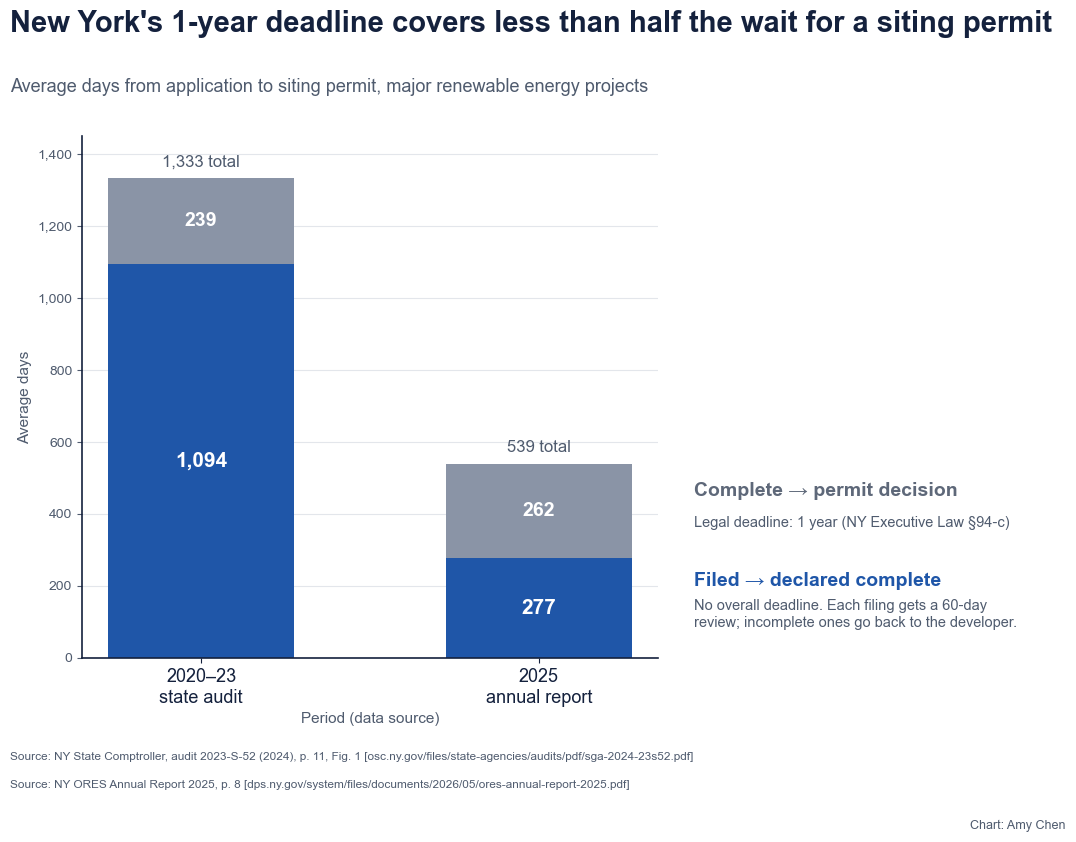

In [11]:
assert (table.share_under_deadline < 0.5).all()

fig = plt.figure(figsize=(12, 9))
ax = fig.add_axes([0.12, 0.22, 0.48, 0.58])
x = [0, 1]
ax.bar(x, table.filed_to_complete_days, width=0.55, color=BLUE)
ax.bar(x, table.complete_to_permit_days, width=0.55, bottom=table.filed_to_complete_days, color=GREY)
for i, r in table.iterrows():
    ax.text(i, r.filed_to_complete_days / 2, f"{r.filed_to_complete_days:,}", ha="center", va="center", color="white", fontsize=15, fontweight="bold")
    ax.text(i, r.filed_to_complete_days + r.complete_to_permit_days / 2, f"{r.complete_to_permit_days:,}", ha="center", va="center", color="white", fontsize=14, fontweight="bold")
    ax.text(i, r.total_days + 25, f"{r.total_days:,} total", ha="center", va="bottom", color=MUTED, fontsize=12)
ax.set_xticks(x, ["2020–23\nstate audit", "2025\nannual report"], fontsize=13)
ax.set_xlabel("Period (data source)", fontsize=11)
ax.set_ylabel("Average days", fontsize=11)
ax.set_ylim(0, 1450)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.set_axisbelow(True)

# Direct labels beside the 2025 column, saying exactly what each stage is.
fig.text(0.63, 0.30, "Filed → declared complete", color=BLUE, fontsize=14, fontweight="bold")
fig.text(0.63, 0.255, "No overall deadline. Each filing gets a 60-day\nreview; incomplete ones go back to the developer.", color=MUTED, fontsize=10.5)
fig.text(0.63, 0.40, "Complete → permit decision", color="#5E6879", fontsize=14, fontweight="bold")
fig.text(0.63, 0.365, "Legal deadline: 1 year (NY Executive Law §94-c)", color=MUTED, fontsize=10.5)

frame_chart(
    fig,
    "New York's 1-year deadline covers less than half the wait for a siting permit",
    "Average days from application to siting permit, major renewable energy projects",
    [("NY State Comptroller, audit 2023-S-52 (2024), p. 11, Fig. 1", "osc.ny.gov/files/state-agencies/audits/pdf/sga-2024-23s52.pdf"),
     ("NY ORES Annual Report 2025, p. 8", "dps.ny.gov/system/files/documents/2026/05/ores-annual-report-2025.pdf")],
)
fig.savefig(OUTPUT / "ny_siting_clock.png", dpi=200)
plt.show()

## Caveats to state alongside the chart

- 2020–23 covers the 14 projects that received permits; some began under the older Article 10 process and were transferred, which adds time before ORES's process starts.
- 2025 covers 9 permits. Small numbers move averages a lot.
- The audit page numbers above are **PDF pages** (page 1 = first page of the file).